# Exploratory Data Analysis - Financial Crisis Prediction

## 1. Introduction
This notebook performs an Exploratory Data Analysis (EDA) on the `global_crisis_data.csv` dataset. The goal is to understand the data structure, identify missing values, analyze distributions, and explore relationships between variables to aid in building a financial crisis prediction model.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PowerTransformer

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Loading
Loading the dataset and the data dictionary.

In [ ]:
# Load data
df = pd.read_csv("https://raw.githubusercontent.com/EtienneDefranc/FinancialCrisis-Predictor/refs/heads/master/before-eda/global_crisis_data.csv")
data_dict = pd.read_csv("https://raw.githubusercontent.com/EtienneDefranc/FinancialCrisis-Predictor/refs/heads/master/before-eda/data_dictionary.csv")

print("Data loaded successfully.")

Data loaded successfully.


## 3. Data Overview
Displaying specific information about the columns, their types, and summary statistics.

In [50]:
# Display first few rows
display(df.head())

,iso3,year,crisis_next_12m,banking_crisis_next_12m,currency_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y
0,AGO,1960.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.21,NaN
1,AGO,1961.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,1.95,NaN
2,AGO,1962.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,2.71,NaN
3,AGO,1963.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.18,NaN
4,AGO,1964.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.50,NaN


In [51]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   iso3                      3864 non-null   object 
 1   year                      3864 non-null   float64
 2   crisis_next_12m           3864 non-null   float64
 3   banking_crisis_next_12m   3864 non-null   float64
 4   currency_crisis_next_12m  3864 non-null   float64
 5   debt_crisis_next_12m      3864 non-null   float64
 6   crisis_any                3864 non-null   int64  
 7   banking_crisis            3864 non-null   int64  
 8   currency_crisis           3864 non-null   int64  
 9   debt_crisis               3864 non-null   int64  
 10  inflation                 3287 non-null   float64
 11  gdp_growth                3563 non-null   float64
 12  unemployment              2077 non-null   float64
 13  fed_funds_rate            3864 non-null   float64
 14  real_int

In [52]:
# Summary statistics
df.describe()

,year,crisis_next_12m,banking_crisis_next_12m,currency_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y
count,3864.000000,3864.000000,3864.000000,3864.0,3864.000000,3864.000000,3864.000000,3864.0,3864.000000,3287.000000,3563.000000,2077.000000,3864.000000,2346.000000
mean,1987.500000,0.243012,0.133282,0.0,0.142340,0.243271,0.133282,0.0,0.142598,26.521509,3.877738,7.361600,5.255536,2.860591
std,16.165322,0.428958,0.339923,0.0,0.349443,0.429113,0.339923,0.0,0.349708,280.326539,4.437960,4.623869,3.546271,1.775946
min,1960.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,-8.422486,-36.391977,0.190000,0.090000,-0.013249
25%,1973.750000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,2.491026,1.792397,4.154000,3.140000,1.445796
50%,1987.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,5.409549,3.967981,6.547000,5.035000,2.800699
75%,2001.250000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,11.616330,6.076601,9.404000,7.270000,4.048303
max,2015.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.0,1.000000,11749.639632,42.410414,31.840000,16.390000,6.934689


## 4. Data Dictionary Analysis
Understanding the variables through the data dictionary.

In [53]:
display(data_dict)

,Column,Description,Source
0,iso3,ISO-3 Country Code,Standard
1,year,Year of observation,Standard
2,crisis_next_12m,TARGET: 1 if ANY crisis starts next year,HBS (Calculated)
3,banking_crisis_next_12m,Specific Target: 1 if Banking Crisis starts ne...,HBS (Calculated)
4,currency_crisis_next_12m,Specific Target: 1 if Currency Crisis starts n...,HBS (Calculated)
5,debt_crisis_next_12m,Specific Target: 1 if Debt Crisis starts next ...,HBS (Calculated)
6,crisis_any,Current State: 1 if any crisis is active,HBS
7,banking_crisis,Current State: 1 if Banking Crisis is active,HBS
8,currency_crisis,Current State: 1 if Currency Crisis is active,HBS
9,debt_crisis,Current State: 1 if Debt Crisis is active,HBS


## 5. Missing Values Analysis

,Missing Values,Percentage
unemployment,1787,46.247412
real_interest_rate_10y,1518,39.285714
inflation,577,14.932712
gdp_growth,301,7.789855


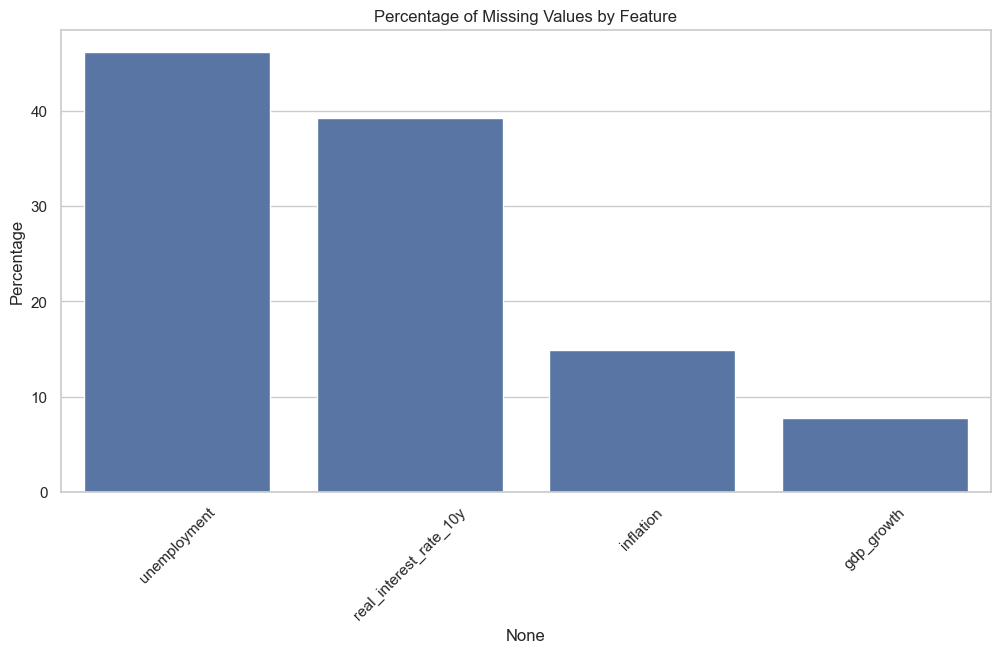

In [54]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
display(missing_data)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data.index, y=missing_data['Percentage'])
plt.xticks(rotation=45)
plt.title('Percentage of Missing Values by Feature')
plt.show()

## 6. Univariate Analysis
Analyzing the distribution of numerical and categorical variables.

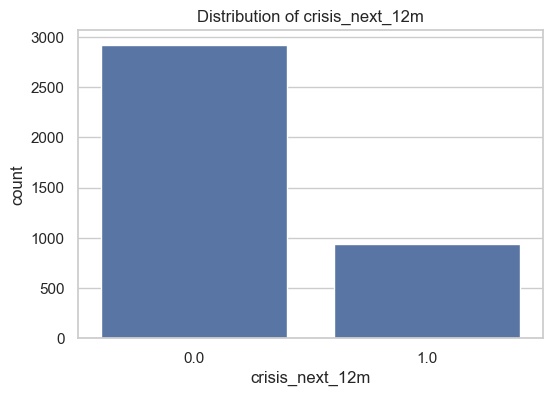

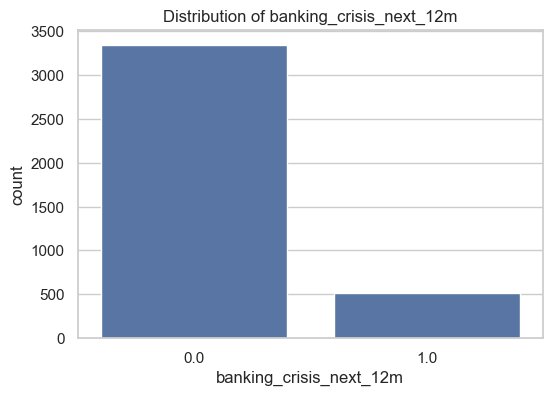

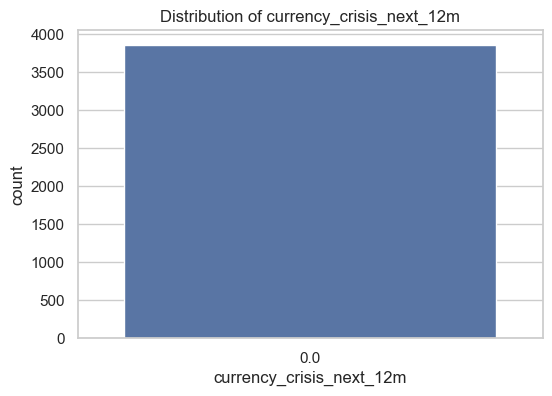

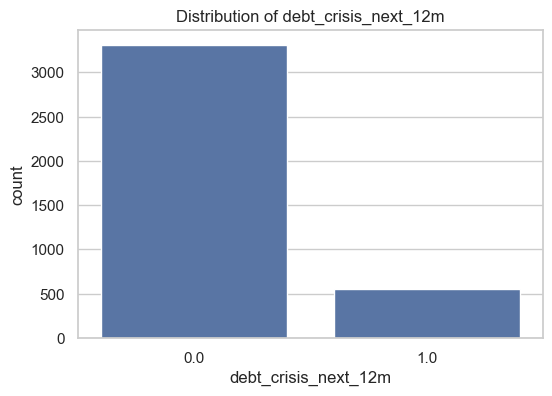

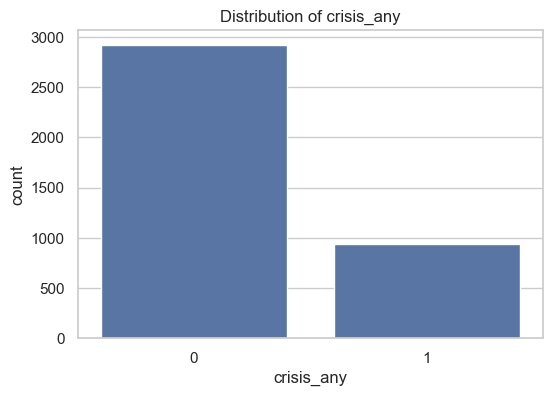

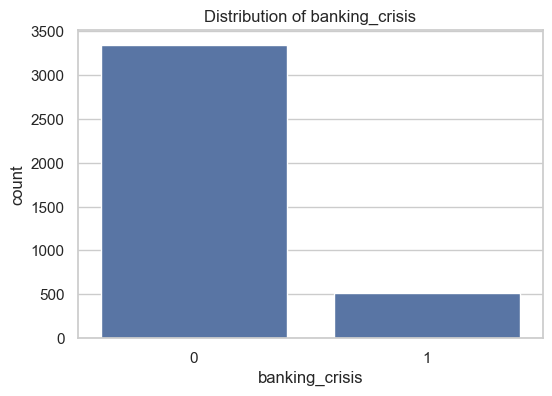

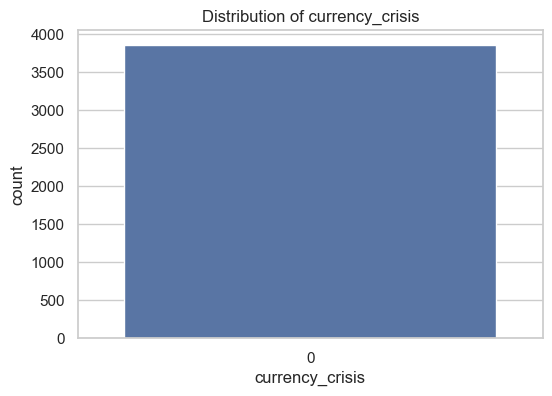

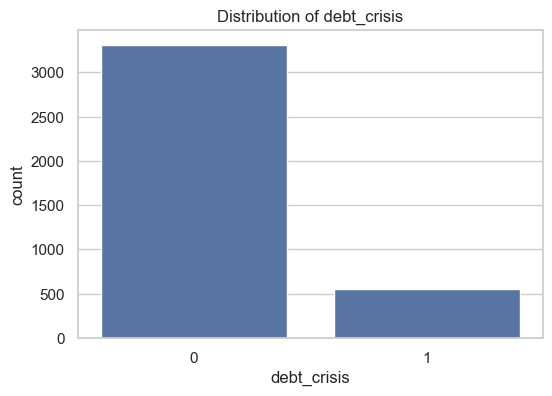

In [55]:
# Categorical/Binary Variables
categorical_cols = ['crisis_next_12m', 'banking_crisis_next_12m', 'currency_crisis_next_12m', 'debt_crisis_next_12m',
                    'crisis_any', 'banking_crisis', 'currency_crisis', 'debt_crisis']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

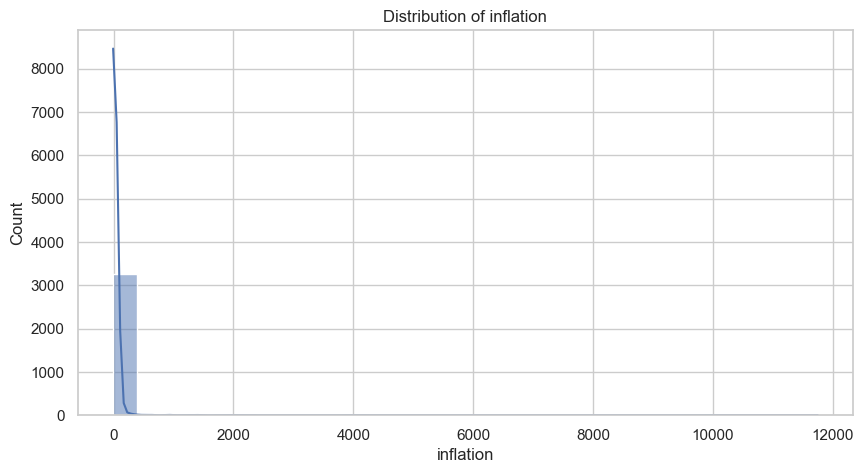

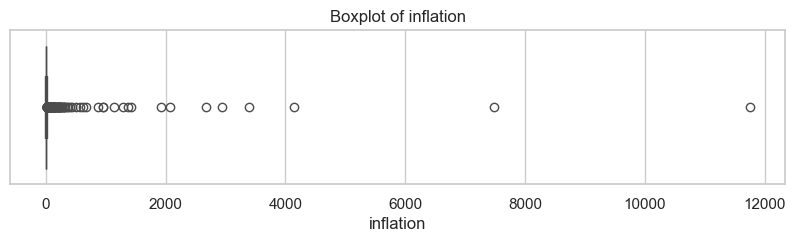

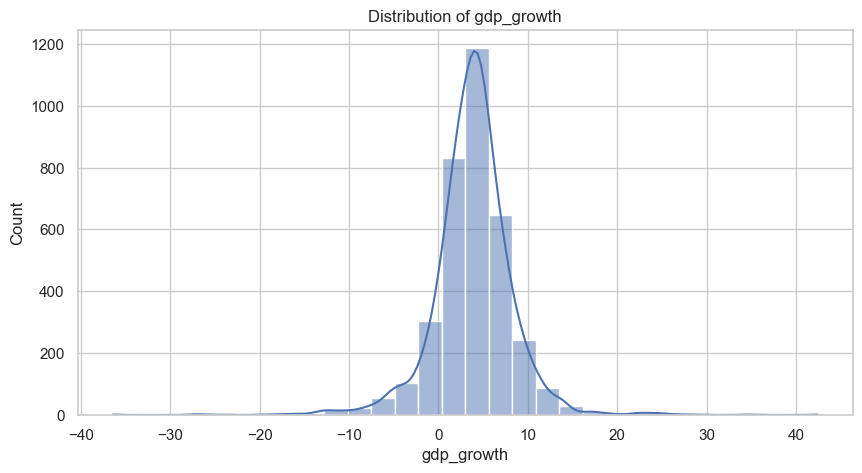

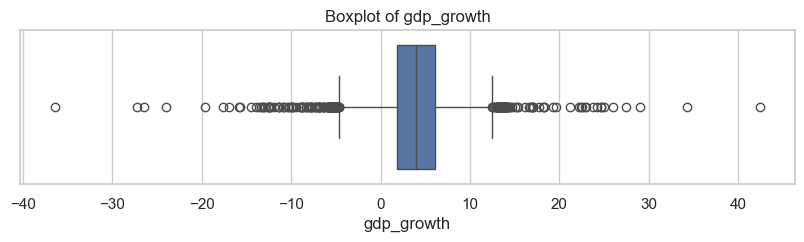

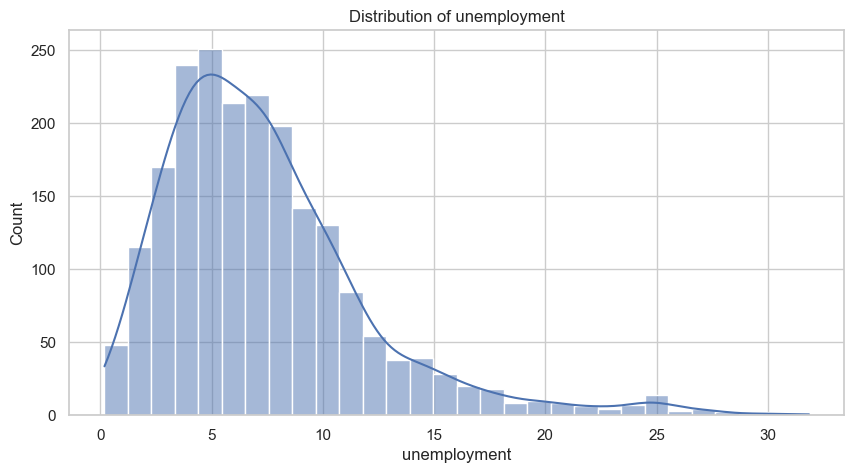

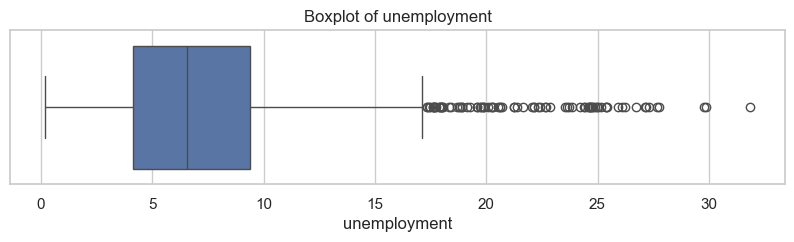

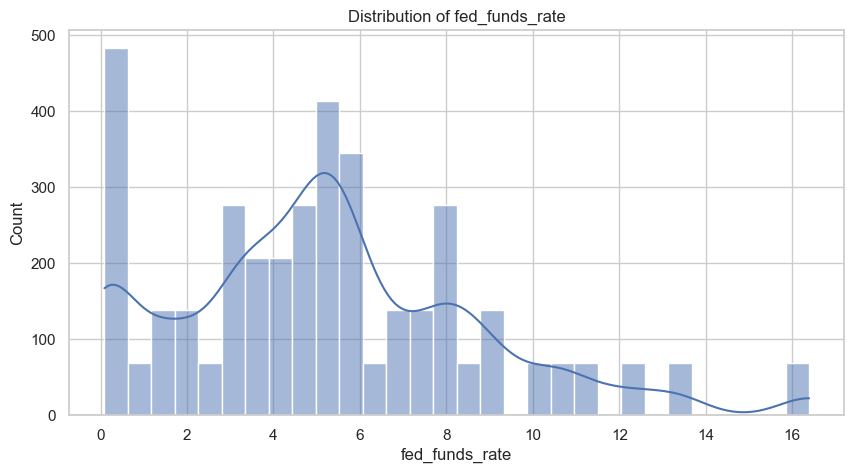

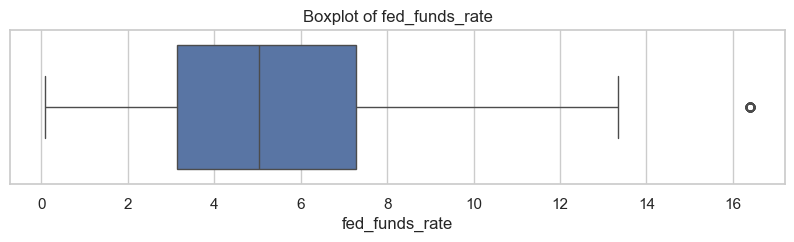

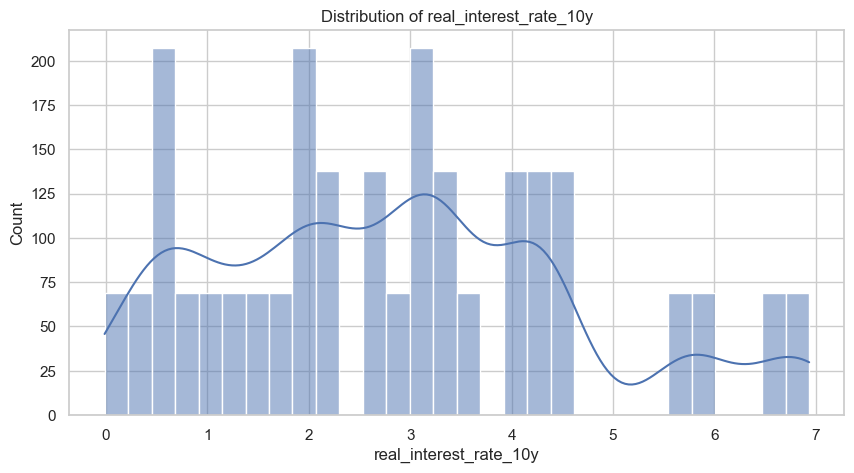

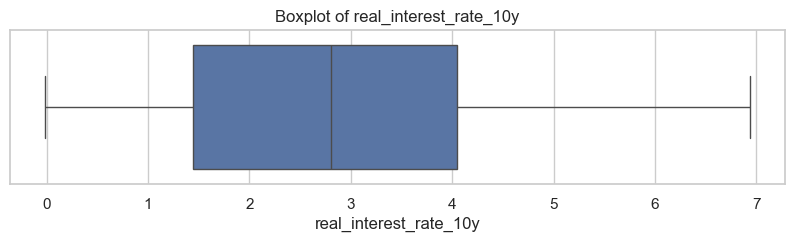

In [56]:
# Numerical Variables
numerical_cols = ['inflation', 'gdp_growth', 'unemployment', 'fed_funds_rate', 'real_interest_rate_10y']

for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()
    
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## 7. Bivariate/Multivariate Analysis
Exploring relationships between variables.

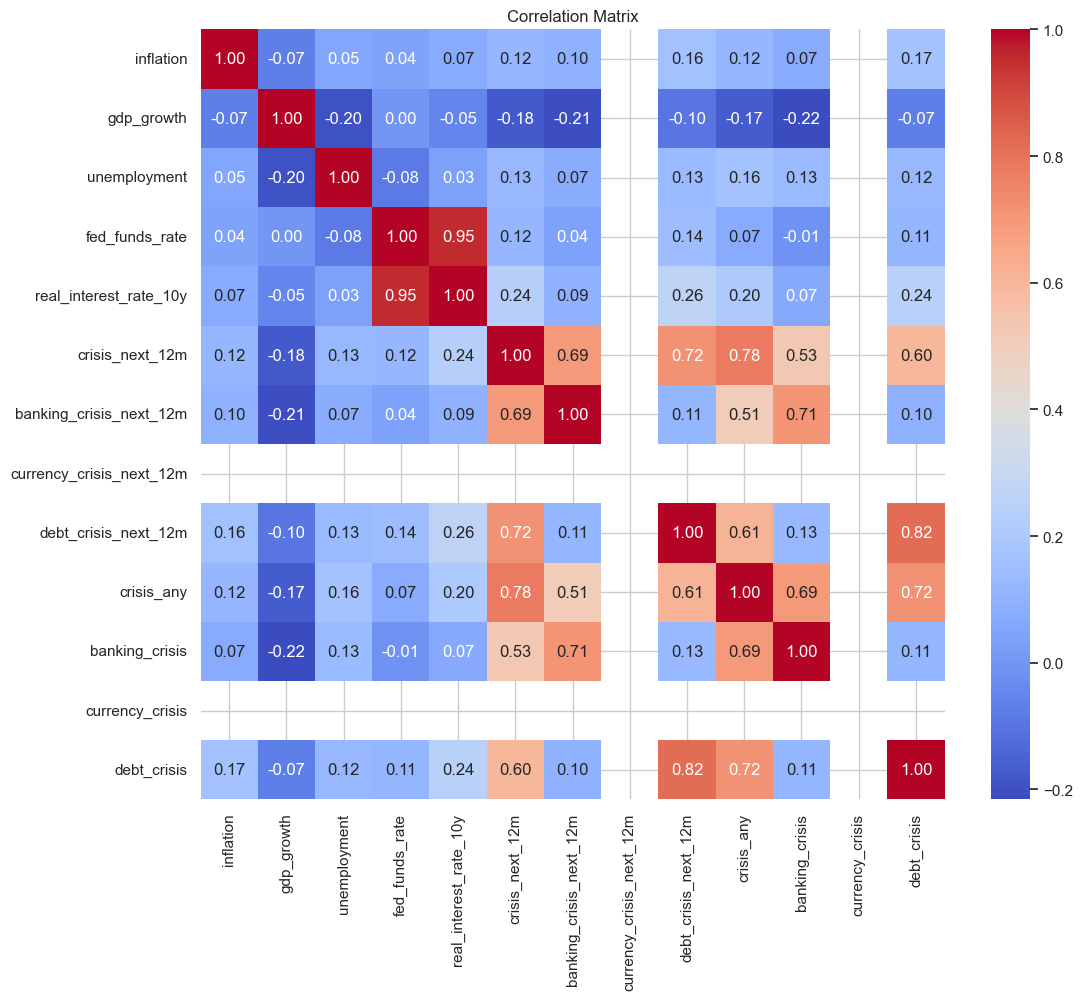

In [57]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols + categorical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

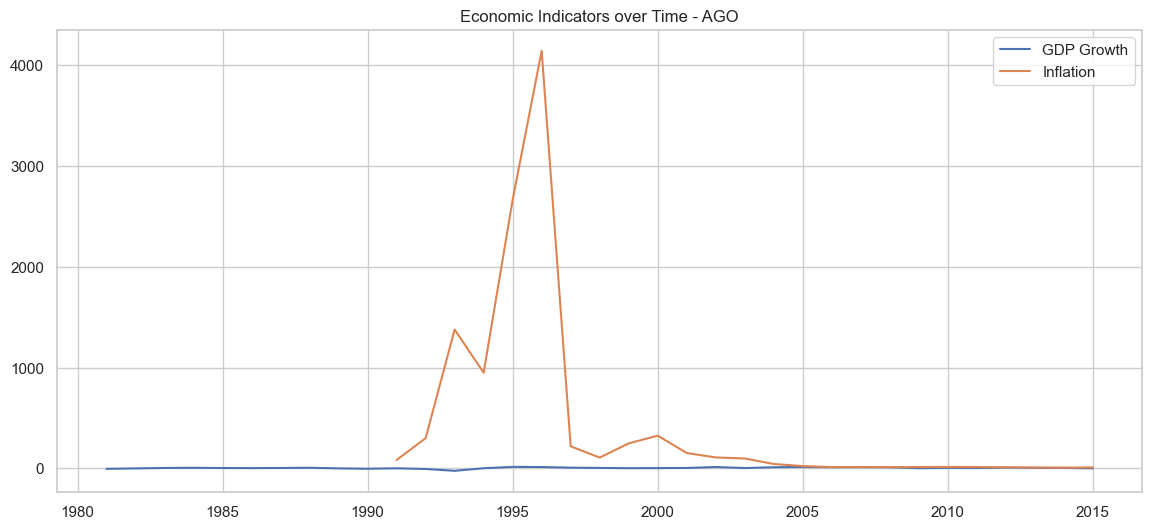

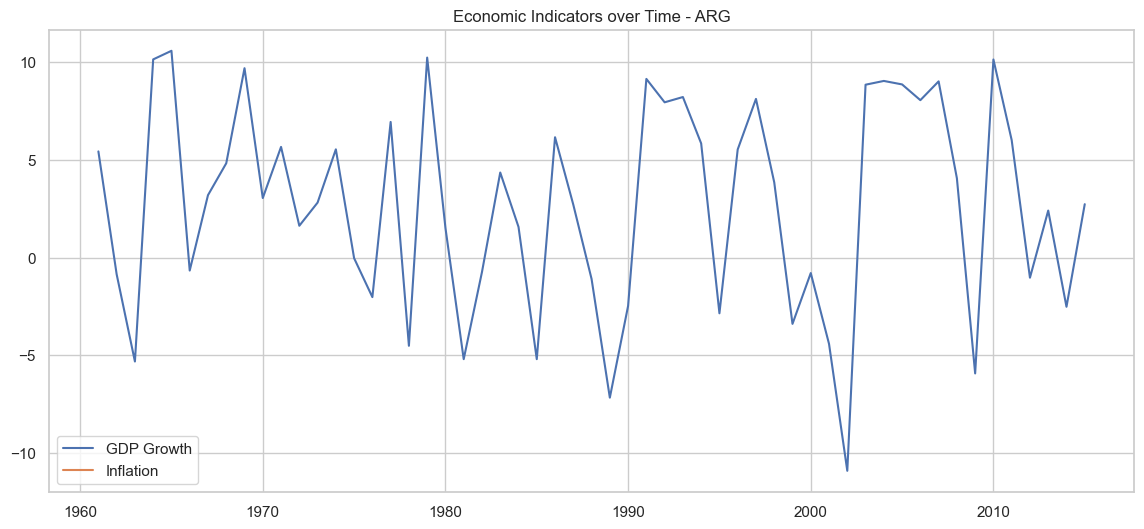

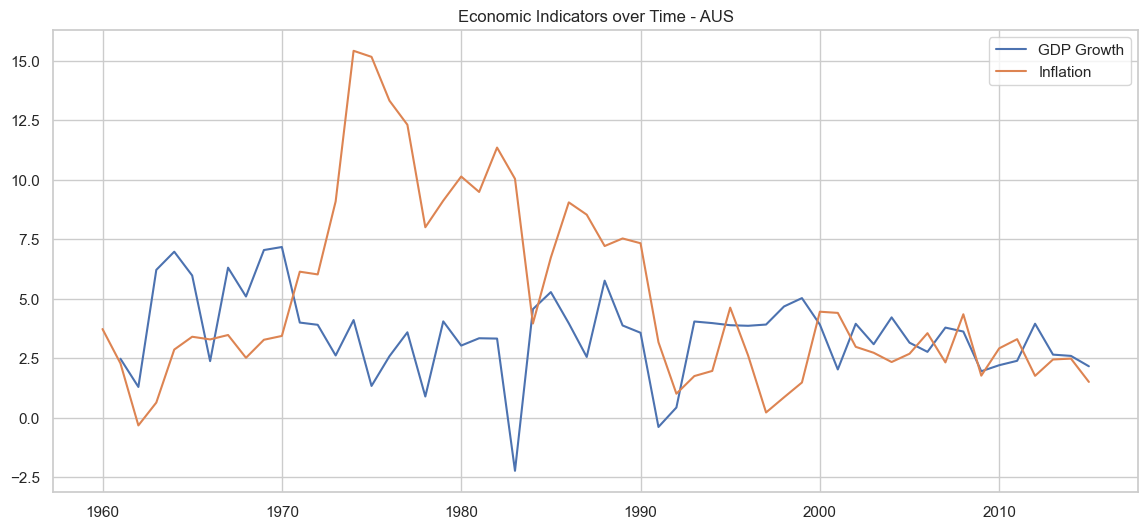

In [58]:
# Time Series Analysis for a few countries
countries = df['iso3'].unique()[:3] # Taking first 3 countries for demo

for country in countries:
    country_data = df[df['iso3'] == country]
    plt.figure(figsize=(14, 6))
    plt.plot(country_data['year'], country_data['gdp_growth'], label='GDP Growth')
    plt.plot(country_data['year'], country_data['inflation'], label='Inflation')
    plt.title(f'Economic Indicators over Time - {country}')
    plt.legend()
    plt.show()

## 8. Conclusion
Summary of the findings from the EDA.

## 9. Data Cleaning and Imputation
Analyzing variables for removal or imputation based on the previous findings.

In [59]:
# 1. High Missing Values Handling
# If a column has more than 50% missing values, it might be better to drop it unless it's critical.
threshold = 50
columns_to_drop = missing_data[missing_data['Percentage'] > threshold].index
print(f"Columns with > {threshold}% missing values: {list(columns_to_drop)}")

# Logic checking for critical columns before dropping
# Assuming 'real_interest_rate_10y' or 'unemployment' might be in this list.
# We will drop them for this analysis demo if they exceed the threshold, but in a real scenario, domain knowledge is key.
df_cleaned = df.drop(columns=columns_to_drop)
print("Dropped columns.")

# 2. Imputation for Numerical Columns
# For remaining numerical columns, we can Impute with median (robust to outliers) or linear interpolation (good for time series).
# Since this is time-series data per country, interpolation is often better.

impute_cols = [col for col in numerical_cols if col in df_cleaned.columns and df_cleaned[col].isnull().sum() > 0]

for col in impute_cols:
    # Group by country and interpolate
    df_cleaned[col] = df_cleaned.groupby('iso3')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    # If there are still missing values (e.g., a country has NO data for a column), fill with the global median
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

print("Imputed numerical columns.")

# 3. Imputation for Categorical/Target Columns
# Target columns should ideally not be imputed if they are missing, but rather those rows dropped.
# However, if they are just 0/1 binary and not 'missing', we check.
# If there are missing values in crisis indicators (which shouldn't happen based on the head), we'll fill with 0 (assuming no crisis if not recorded).
target_cols = [col for col in categorical_cols if col in df_cleaned.columns]
for col in target_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(0)
        print(f"Filled missing in primary target {col} with 0")

# Verify cleaning
print("Remaining missing values:")
print(df_cleaned.isnull().sum().sum())

Columns with > 50% missing values: []
Dropped columns.
Imputed numerical columns.
Remaining missing values:
0


## 10. Skewness Analysis and Correction
Analyzing skewness and applying Yeo-Johnson transformation.

Skewness before transformation:
inflation                 28.911248
gdp_growth                -0.575364
unemployment               1.444117
fed_funds_rate             0.699424
real_interest_rate_10y    -0.293913
dtype: float64

Highly skewed columns: ['inflation', 'unemployment']

Skewness after transformation:
inflation                -1.884145
gdp_growth               -0.575364
unemployment             -0.000935
fed_funds_rate            0.699424
real_interest_rate_10y   -0.293913
dtype: float64


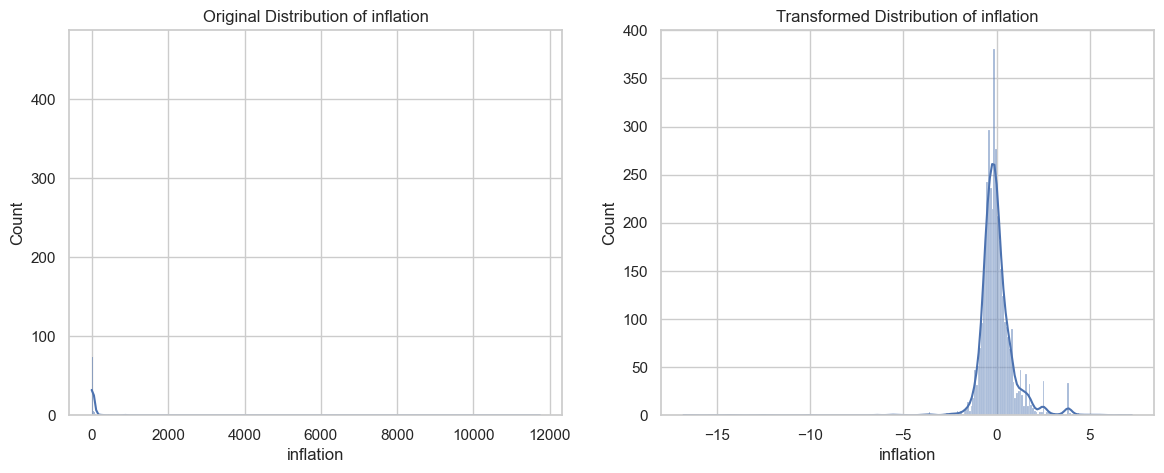

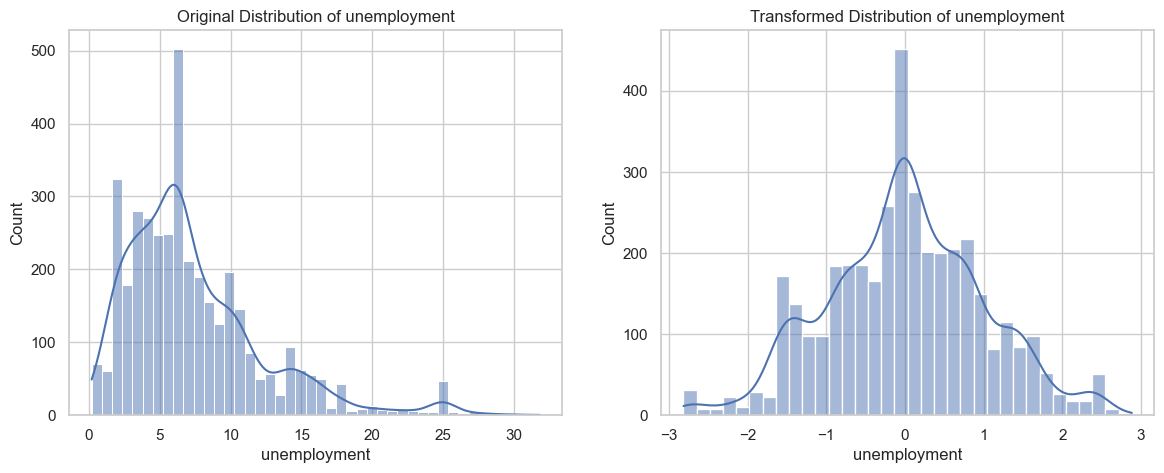

In [60]:
# Calculate Skewness
numeric_features = df_cleaned.select_dtypes(include=[np.number]).columns
# Filter for only continuous numerical features, excluding binary targets and 'year'
skew_features = [col for col in numerical_cols if col in df_cleaned.columns]

skewness = df_cleaned[skew_features].skew()
print("Skewness before transformation:")
print(skewness)

# Identify highly skewed features (|skewness| > 1)
high_skew_cols = skewness[abs(skewness) > 1].index
print(f"\nHighly skewed columns: {list(high_skew_cols)}")

# Apply Yeo-Johnson Transformation (supports negative values)
pt = PowerTransformer(method='yeo-johnson')

df_transformed = df_cleaned.copy()
if len(high_skew_cols) > 0:
    df_transformed[high_skew_cols] = pt.fit_transform(df_cleaned[high_skew_cols])

    print("\nSkewness after transformation:")
    print(df_transformed[skew_features].skew())

    # Visualize before and after
    for col in high_skew_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        sns.histplot(df_cleaned[col], kde=True, ax=axes[0])
        axes[0].set_title(f'Original Distribution of {col}')
        
        sns.histplot(df_transformed[col], kde=True, ax=axes[1])
        axes[1].set_title(f'Transformed Distribution of {col}')
        
        plt.show()
else:
    print("No highly skewed columns found.")

## 11. Feature Selection and Engineering
Removing redundant features based on correlation analysis.

In [61]:
# 1. Drop Highly Correlated Features
# 'fed_funds_rate' has 0.95 correlation with 'real_interest_rate_10y'
if 'fed_funds_rate' in df_transformed.columns:
    df_final = df_transformed.drop(columns=['fed_funds_rate'])
    print("Dropped 'fed_funds_rate' due to high multicollinearity.")
else:
    df_final = df_transformed
    print("'fed_funds_rate' already removed or not present.")

# 2. Check and Drop Empty/Constant Columns
# 'currency_crisis_next_12m' showed empty in correlation matrix
if 'currency_crisis_next_12m' in df_final.columns:
    # Check variance or if all values are null/same
    if df_final['currency_crisis_next_12m'].nunique() <= 1:
        df_final = df_final.drop(columns=['currency_crisis_next_12m'])
        print("Dropped 'currency_crisis_next_12m' due to zero variance/constant values.")
    else:
        print("'currency_crisis_next_12m' has variance, keeping it.")

Dropped 'fed_funds_rate' due to high multicollinearity.
Dropped 'currency_crisis_next_12m' due to zero variance/constant values.


## 12. Dataset Export
Saving the finally processed and cleaned dataset.

In [62]:
# Save Processed Data
output_file = 'global_crisis_data_cleaned.csv'
df_final.to_csv(output_file, index=False)
print(f"\nFinal cleaned dataset exported to: {output_file}")
print(f"Final dataframe shape: {df_final.shape}")


Final cleaned dataset exported to: global_crisis_data_cleaned.csv
Final dataframe shape: (3864, 13)
